## Decision-Making Under Uncertainty: Learning From Experience



#### 1. Introduction: 

Risky decisions are taken on an everyday basis. Examples include investment decisions, buying insurance, buying lottery tickets, what major to pursue in college, what career path to choose, and so on. Many of these cases involve learning from experience rather than description. This is because probabilities and outcomes are not explicitly known, but can be inferred from enough exploration. Understanding how to optimally learn from sequential experience in a risky environment is important in financial, business, medical, technological, and many other real-world contexts. 

A mathematical framework that studies decision making in experience scenarios is called the multi-armed bandit problem. In this setting the decision maker sequentially chooses one of multiple choices where the properties of each choice are only partially known at the time of the choice, and may become better understood through more trials.

In this project we will focus on choices between two alternatives- a safe one that yields a medium outcome with certainty and a risky one that yields different outcomes with different probabilities. The decision maker will  repeatedly choose between these two options and observe and receive the outcomes. He or she gradually learns about the expected payoffs of the options and can make more informative subsequent decisions to increase his or her total payoffs. We model this learning process and simulate different decision strategies to see how beliefs evolve over time and how they influence choice behavior.    

#### 2. Mathematical Model 

##### 2.1. Multi-Armed Bandit

The name 'multi-armed bandit' originates from slot machines in casinos, where each machine represents an “arm” that produces rewards with some probability distribution. A decision maker repeatedly chooses which arm to pull and receives rewards that depend on the selected arm. 

Formally, consider a set of $K$ available actions (or arms): $A = {1,2,...,K}$. Each arm $i$ is associated with an unknown reward distribution with expected value $\mu_i = E[R_i]$ where $R_i$ denotes the reward obtained when arm $i$ is chosen.

At each time period $t = 1,2,...,T$, the decision maker selects an arm $a_t \in A$.

The goal of the decision maker is to maximize the total payoffs: $\max \sum_{t=1}^{T} R_t$. The classical multi-armed bandit problem also incorporates a regret component in the model. For simplicity reasons, we will adhere to the model without this additional regret component. 


The decision maker has to find a strategy that balances between exploration and exploitation. On the one hand, exploring different arms provides information about their payoff distributions. On the other hand, exploiting the arm that currently appears to yield the highest payoff increases immediate payoffs.

##### 2.2. Two-Armed Case (our setting)

In this project we will focus on a special case of the multi-armed bandit problem, where there are only two options ($K=2$). The action set is then: $A = \{S, R\}$ where $S$ denotes the safe option and $R$ denotes the risky option. At each time period $t = 1,2,\dots,T$, the decision maker chooses an action $a_t \in \{S,R\}$ and observes a realized payoff $R_t$:


$$
R_t =
\begin{cases}
c, & \text{if } a_t = S,\\
X_t, & \text{if } a_t = R,
\end{cases}
$$

where $c > 0$ is a fixed payoff and $X_t$ is a stochastic payoff, taking on the following form: 

$$
X_t =
\begin{cases}
r, & \text{with probability } p,\\
0, & \text{with probability } 1-p.
\end{cases}
$$

where $r$ is a high outcome ($r > c$) and the probability $p$ is the probability to yield $r$. The decision maker does not know the payoff structure of either option in advance. In particular, the decision maker does not initially know that the safe option always yields the same payoff $c$. Instead, the properties of both options must be learned through repeated sampling and observation of realized outcomes.

##### 2.3. Learning from Experience

The decision maker does not know the payoff distributions of either option in advance. The outcomes associated with both the safe and the risky option must therefore be learned through repeated observations of realized rewards. In each period $t = 1,2,\dots,T$, the decision maker chooses an option and observes the resulting payoff.

Let $R_{i,t}$ denote the reward obtained when option $i \in \{S,R\}$ is selected at time $t$. The decision maker forms an estimate of the expected reward of each option based on previously observed outcomes.

Let $n_i(t)$ denote the number of times option $i$ has been chosen up to time $t$. The estimated expected reward of option $i$ is given by the sample mean of observed rewards:

$$
\hat{\mu}_i(t) =
\frac{1}{n_i(t)}
\sum_{k=1}^{n_i(t)} R_{i,k}.
$$

After each new observation, the estimate can be updated incrementally. If option $i$ is chosen at time $t$ and produces reward $R_{i,t}$, the updated estimate becomes

$$
\hat{\mu}_i(t+1) =
\hat{\mu}_i(t)
+
\frac{1}{n_i(t)}
\left(R_{i,t} - \hat{\mu}_i(t)\right).
$$

This updating rule allows the decision maker to revise beliefs about the expected payoff of each option as more information becomes available.

As the number of observations increases, the estimated expected rewards converge toward the true expected rewards of the options. These evolving estimates guide the decision maker's subsequent choices and determine how exploration and exploitation are balanced across periods.

##### 2.4. Decision Strategies

Once the decision maker forms estimates of the expected rewards of the two options, the next step is to determine how these estimates influence the choice of option. Different decision strategies balance exploration and exploitation in different ways. Exploration refers to sampling options in order to learn more about their payoffs and probability distributions. Exploitation refers to selecting the option that currently appears to yield the highest reward.

Let $\hat{\mu}_i(t)$ denote the estimated expected reward of option $i \in \{S,R\}$ at time $t$, based on previously observed outcomes. Below we will look at three popular strategies and how decisions are made under currently available information at time $t$. In the present framework, the decision maker does not explicitly model the probability of success of each option. Instead, the expected rewards of the options are estimated directly from observed outcomes, and the decision strategies are based on these estimated reward values.

2.4.1. Greedy Strategy

A simple strategy is the greedy strategy, which always selects the option with the highest estimated expected reward. The chosen action at time $t$ is:

$$
a_t = \arg\max_{i \in \{S,R\}} \hat{\mu}_i(t).
$$

Under this strategy, the decision maker exploits the option that currently appears to perform best. The main weakness of the greedy strategy is that it is sensitive to early observations and does not encourage exploration. As a result, if an option yields a favorable outcome early on, the decision maker may repeatedly choose that option without collecting additional information about the alternative option.

2.4.2. Upper Confidence Bound (UCB)

The Upper Confidence Bound (UCB) strategy introduces an explicit mechanism for balancing exploration and exploitation (Auer, 2002). In addition to the estimated expected reward, the decision maker considers the uncertainty associated with that estimate.

At time period $t$, the decision maker selects the option that maximizes

$$
a_t = \arg\max_{i \in \{S,R\}}
\left(
\hat{\mu}_i(t) +
\sqrt{\frac{2 \ln t}{n_i(t)}}
\right),
$$

where $n_i(t)$ denotes the number of times option $i$ has been selected up to time $t$.

The first term represents the estimated expected reward of the option, while the second term is an exploration term. As the number of observations increases, the exploration term decreases, and the strategy gradually favors the option with the higher estimated payoff.

2.4.3. Thompson Sampling

Thompson Sampling is a probabilistic strategy that balances exploration and exploitation by selecting actions according to their probability of being optimal (Thompson, 1933). Instead of choosing the option with the highest current estimate, the decision maker samples a plausible value of the expected reward for each option.

Let $\tilde{\mu}_i(t)$ denote a sampled value representing a plausible expected reward of option $i$. A simple approximation is to draw this value from a normal distribution centered at the estimated reward:

$$
\tilde{\mu}_i(t) \sim \mathcal{N}\!\left(\hat{\mu}_i(t),\; \frac{\sigma_0^2}{n_i(t)}\right),
$$

where $\sigma_0^2$ represents the initial uncertainty about the expected reward of the option.

At each time period $t$, the decision maker chooses the option with the highest sampled value:

$$
a_t = \arg\max_{i \in \{S,R\}} \tilde{\mu}_i(t).
$$

Options that have been sampled fewer times have greater uncertainty and more dispersed sampling distributions. They could generate a high sampled value with a greter probability, which encourages exploration but also favors the option with the higher estimated payoff.

#### 3. Python Implementation

##### 3.1. Environmental Setup

To study how different decision strategies perform in this binary choice environment, we conduct a series of simulations in Python. The decision maker repeatedly chooses between a safe option and a risky option over a finite time horizon $T$. The safe option yields a constant payoff $c$, while the risky option yields a payoff $r$ with probability $p$ and zero otherwise. The decision maker does not know initially the payoffs of the options and the probabilities with which they occur. Instead, the probaibilities and outcomes of the options must be learned through repeated sampling and observation of realized outcomes.

Let $\hat{\mu}_i(t)$ denote the estimated expected reward of option $i \in \{S,R\}$ at time $t$. At each time period the decision maker selects an option according to a particular decision strategy. After each choice the realized payoff of option $i$ is incorporated into the estimate of the corresponding option's expected reward.

The performance of the different decision strategies is evaluated by comparing the cumulative payoffs obtained over time. We vary the probability of the risky option, the expected values of the options, and the time horizon for a detailed analysis of how the performance varies when key features of the environment also vary.

##### 3.2. Python Code

In [2]:
# Import libraries for numerical computation and plotting

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Environmental Parameters

T = 1000         # number of time periods
c = 3            # payoff of the safe option
r = 4            # payoff of the high outcome of the risky option
p = 0.8          # probability of getting the high outcome of the risky option

In [12]:
# Thompson Strategy

# Lists of choices made and rewards received

choices_ts = []
rewards_ts = []

# Counts of option choices and mean rewards (initial mean rewards set to 0)

n_S, n_R = 0, 0
Q_S, Q_R = 0.0, 0.0

sigma0 = 10.0  # Initial variance parameter (greater coefficient encourages more exploration)  

for t in range(T):

    #
    if n_S == 0:
        choice = "S"
    elif n_R == 0:
        choice = "R"
    else:
        # Sample a plausible mean reward for each option
        sample_S = np.random.normal(Q_S, sigma0 / np.sqrt(n_S))
        sample_R = np.random.normal(Q_R, sigma0 / np.sqrt(n_R))

        choice = "R" if sample_R > sample_S else "S"

    choices_ts.append(choice)

    # Reward Outcomes
    if choice == "S":
        reward = c
        n_S += 1
        Q_S += (reward - Q_S) / n_S
    else:
        success = np.random.rand() < p
        reward = r * success
        n_R += 1
        Q_R += (reward - Q_R) / n_R

    rewards_ts.append(reward)

cumulative_rewards_thompson = np.cumsum(rewards_ts)

print("Thompson Strategy")
print("Safe chosen:", choices_ts.count("S"))
print("Risky chosen:", choices_ts.count("R"))

Thompson Strategy
Safe chosen: 405
Risky chosen: 595


In [13]:
# Greedy strategy

# Lists of choices made and rewards received

choices_greedy = []
rewards_greedy = []

# Counts of option choices and mean rewards (initial mean rewards set to 0)

n_S, n_R = 0, 0
Q_S, Q_R = 0.0, 0.0

for t in range(T):

    # Force each option to be chosen at least once (to ensure that we divide by a non-zero number when calculating estimated mean rewards)
    if n_S == 0 and n_R == 0:
        choice = "R" if np.random.rand() < 0.5 else "S"
    elif n_S == 0:
        choice = "S"
    elif n_R == 0:
        choice = "R"
    else:
        if Q_R > Q_S:
            choice = "R"
        elif Q_S > Q_R:
            choice = "S"
        else:
            choice = "R" if np.random.rand() < 0.5 else "S"

    choices_greedy.append(choice)

    # Reward Outcomes
    if choice == "S":
        reward = c
        n_S += 1
        Q_S += (reward - Q_S) / n_S  
    else:
        success = np.random.rand() < p
        reward = r * success
        n_R += 1
        Q_R += (reward - Q_R) / n_R

    rewards_greedy.append(reward)

cumulative_rewards_greedy = np.cumsum(rewards_greedy)

print("Greedy Strategy")
print("Safe chosen:", choices_greedy.count("S"))
print("Risky chosen:", choices_greedy.count("R"))

Greedy Strategy
Safe chosen: 935
Risky chosen: 65


In [14]:
# UCB strategy 

# Lists of choices made and rewards received

choices_ucb = []
rewards_ucb = []

# Counts of option choices and mean rewards (initial mean rewards set to 0)

n_S, n_R = 0, 0
Q_S, Q_R = 0.0, 0.0


for t in range(1, T + 1):

    # Force each option to be chosen at least once (to ensure that we divide by a non-zero number when calculating estimated mean rewards)
    if n_S == 0:
        choice = "S"
    elif n_R == 0:
        choice = "R"
    else:
        ucb_S = Q_S + np.sqrt(2 * np.log(t) / n_S)
        ucb_R = Q_R + np.sqrt(2 * np.log(t) / n_R)
        
        if ucb_R > ucb_S:
            choice = "R"
        elif ucb_S > ucb_R:
            choice = "S"
        else:
            choice = "R" if np.random.rand() < 0.5 else "S"

    choices_ucb.append(choice)

    # Reward Outcomes
    if choice == "S":
        reward = c
        n_S += 1
        Q_S += (reward - Q_S) / n_S
    else:
        success = np.random.rand() < p
        reward = r * success
        n_R += 1
        Q_R += (reward - Q_R) / n_R

    rewards_ucb.append(reward)

cumulative_rewards_ucb = np.cumsum(rewards_ucb)

print("UCB Strategy")
print("Safe chosen:", choices_ucb.count("S"))
print("Risky chosen:", choices_ucb.count("R"))

UCB Strategy
Safe chosen: 103
Risky chosen: 897


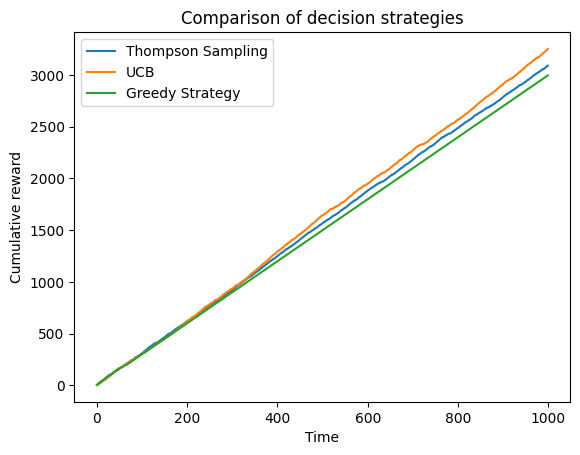

In [15]:
plt.plot(cumulative_rewards_thompson, label="Thompson Sampling")
plt.plot(cumulative_rewards_ucb, label="UCB")
plt.plot(cumulative_rewards_greedy, label="Greedy Strategy")

plt.xlabel("Time")
plt.ylabel("Cumulative reward")
plt.title("Comparison of decision strategies")
plt.legend()
plt.show()

In [18]:
print("UCB:  S =", choices_ucb.count("S"), " R =", choices_ucb.count("R"))
print("Greedy:  S =", choices_greedy.count("S"), " R =", choices_greedy.count("R"))
print("Thompson:S =", choices_ts.count("S"), " R =", choices_ts.count("R"))

UCB:  S = 103  R = 897
Greedy:  S = 935  R = 65
Thompson:S = 405  R = 595


##### 3.3 Monte Carlo Simulation 

The above simulations purely illustrate how the three decision strategies operate over time in a sequential choice environment. In order to have more general and stronger claims on which strategy performs better or which strategy generates more risky or safe choices on average, we need to adhere to a Monte Carlo analysis. Monte Carlo is a computational algorithm that uses repeated random sampling to obtain the likelihood of possible outcomes of an unknown event. Below I provide the Monte Carlo simulation code for four different environments. We vary the time horizon of the sequential choices ($T=1000$ versus $T=40$) and the features of the risky option ($p=0.8$ and $r=4$ versus $p=0.5$ and $r=7$).    

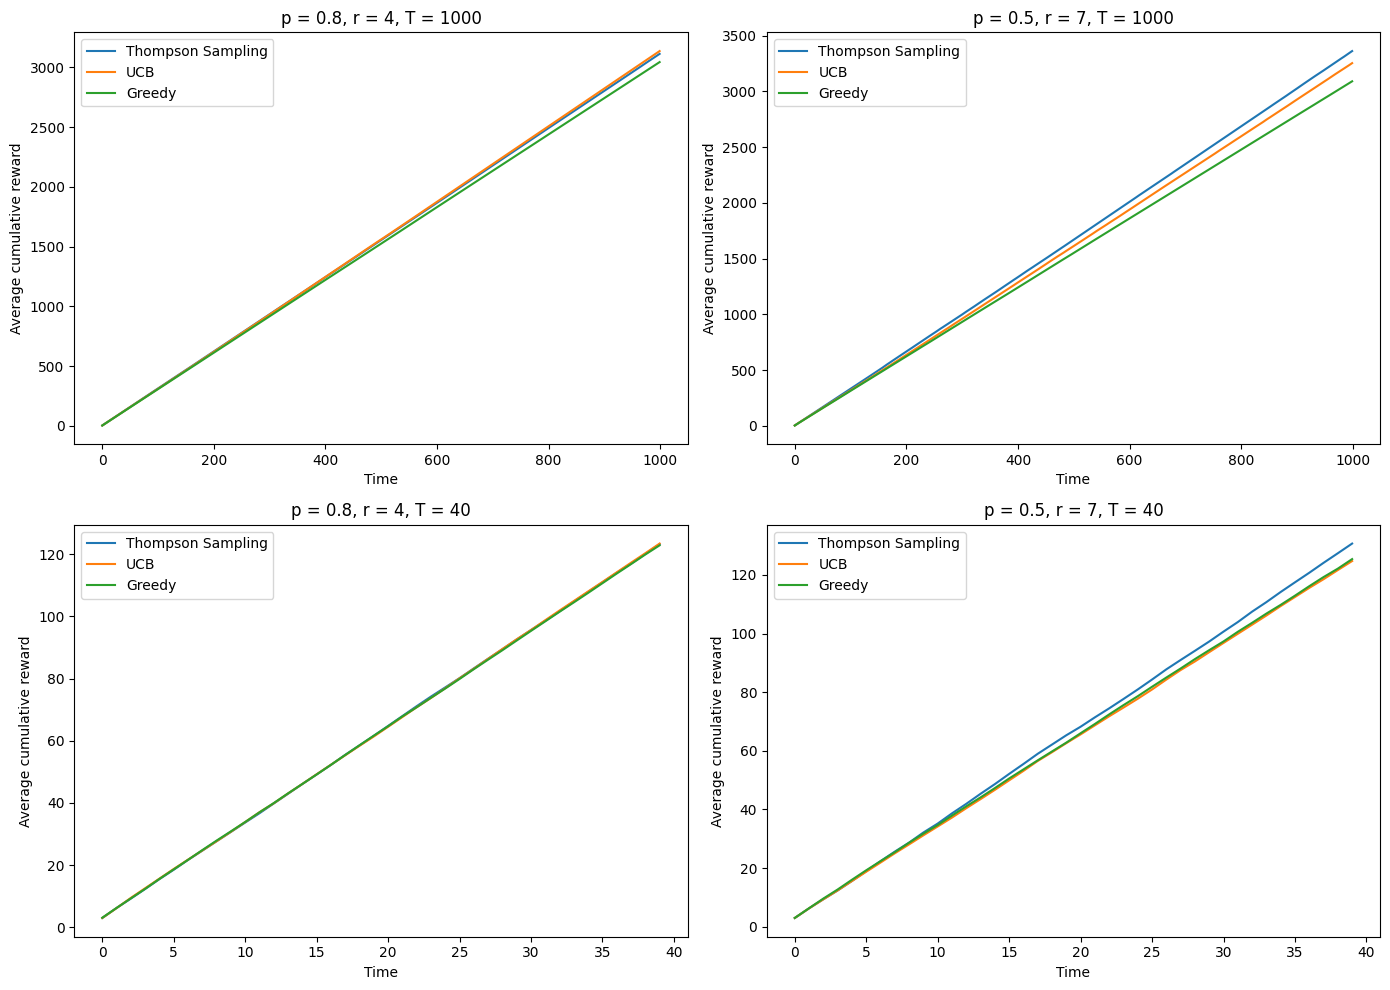

In [4]:
# Import libraries for numerical computation and plotting

import numpy as np
import matplotlib.pyplot as plt

# Payoff of the safe option
c = 3

# Number of Monte Carlo repetitions
n_runs = 300

# Create graphs for the four environments
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# ENVIRONMENT 1: p = 0.8, r = 4, T = 1000

T = 1000
r = 4
p = 0.8

avg_cumulative_rewards_thompson = np.zeros(T)
avg_cumulative_rewards_ucb = np.zeros(T)
avg_cumulative_rewards_greedy = np.zeros(T)

for run in range(n_runs):

    # Thompson Sampling
    choices_ts = []
    rewards_ts = []

    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0

    sigma0 = 10.0

    for t in range(T):

        if n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            sample_S = np.random.normal(Q_S, sigma0 / np.sqrt(n_S))
            sample_R = np.random.normal(Q_R, sigma0 / np.sqrt(n_R))
            choice = "R" if sample_R > sample_S else "S"

        choices_ts.append(choice)

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_ts.append(reward)

    avg_cumulative_rewards_thompson += np.cumsum(rewards_ts)

    # Greedy
    choices_greedy = []
    rewards_greedy = []

    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0

    for t in range(T):

        if n_S == 0 and n_R == 0:
            choice = "R" if np.random.rand() < 0.5 else "S"
        elif n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            if Q_R > Q_S:
                choice = "R"
            elif Q_S > Q_R:
                choice = "S"
            else:
                choice = "R" if np.random.rand() < 0.5 else "S"

        choices_greedy.append(choice)

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_greedy.append(reward)

    avg_cumulative_rewards_greedy += np.cumsum(rewards_greedy)

    # UCB
    choices_ucb = []
    rewards_ucb = []

    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0

    for t in range(1, T + 1):

        if n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            ucb_S = Q_S + np.sqrt(2 * np.log(t) / n_S)
            ucb_R = Q_R + np.sqrt(2 * np.log(t) / n_R)

            if ucb_R > ucb_S:
                choice = "R"
            elif ucb_S > ucb_R:
                choice = "S"
            else:
                choice = "R" if np.random.rand() < 0.5 else "S"

        choices_ucb.append(choice)

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_ucb.append(reward)

    avg_cumulative_rewards_ucb += np.cumsum(rewards_ucb)

avg_cumulative_rewards_thompson /= n_runs
avg_cumulative_rewards_greedy /= n_runs
avg_cumulative_rewards_ucb /= n_runs

axes[0, 0].plot(avg_cumulative_rewards_thompson, label="Thompson Sampling")
axes[0, 0].plot(avg_cumulative_rewards_ucb, label="UCB")
axes[0, 0].plot(avg_cumulative_rewards_greedy, label="Greedy")
axes[0, 0].set_title("p = 0.8, r = 4, T = 1000")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Average cumulative reward")
axes[0, 0].legend()


# ENVIRONMENT 2: p = 0.5, r = 7, T = 1000


T = 1000
r = 7
p = 0.5

avg_cumulative_rewards_thompson = np.zeros(T)
avg_cumulative_rewards_ucb = np.zeros(T)
avg_cumulative_rewards_greedy = np.zeros(T)

for run in range(n_runs):

    # Thompson Sampling
    choices_ts = []
    rewards_ts = []

    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0

    sigma0 = 10.0

    for t in range(T):

        if n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            sample_S = np.random.normal(Q_S, sigma0 / np.sqrt(n_S))
            sample_R = np.random.normal(Q_R, sigma0 / np.sqrt(n_R))
            choice = "R" if sample_R > sample_S else "S"

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_ts.append(reward)

    avg_cumulative_rewards_thompson += np.cumsum(rewards_ts)

    # Greedy
    choices_greedy = []
    rewards_greedy = []

    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0

    for t in range(T):

        if n_S == 0 and n_R == 0:
            choice = "R" if np.random.rand() < 0.5 else "S"
        elif n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            if Q_R > Q_S:
                choice = "R"
            elif Q_S > Q_R:
                choice = "S"
            else:
                choice = "R" if np.random.rand() < 0.5 else "S"

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_greedy.append(reward)

    avg_cumulative_rewards_greedy += np.cumsum(rewards_greedy)

    # UCB
    choices_ucb = []
    rewards_ucb = []

    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0

    for t in range(1, T + 1):

        if n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            ucb_S = Q_S + np.sqrt(2 * np.log(t) / n_S)
            ucb_R = Q_R + np.sqrt(2 * np.log(t) / n_R)

            if ucb_R > ucb_S:
                choice = "R"
            elif ucb_S > ucb_R:
                choice = "S"
            else:
                choice = "R" if np.random.rand() < 0.5 else "S"

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_ucb.append(reward)

    avg_cumulative_rewards_ucb += np.cumsum(rewards_ucb)

avg_cumulative_rewards_thompson /= n_runs
avg_cumulative_rewards_greedy /= n_runs
avg_cumulative_rewards_ucb /= n_runs

axes[0, 1].plot(avg_cumulative_rewards_thompson, label="Thompson Sampling")
axes[0, 1].plot(avg_cumulative_rewards_ucb, label="UCB")
axes[0, 1].plot(avg_cumulative_rewards_greedy, label="Greedy")
axes[0, 1].set_title("p = 0.5, r = 7, T = 1000")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("Average cumulative reward")
axes[0, 1].legend()


# ENVIRONMENT 3: p = 0.8, r = 4, T = 40


T = 40
r = 4
p = 0.8

avg_cumulative_rewards_thompson = np.zeros(T)
avg_cumulative_rewards_ucb = np.zeros(T)
avg_cumulative_rewards_greedy = np.zeros(T)

for run in range(n_runs):

    # Thompson Sampling
    rewards_ts = []
    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0
    sigma0 = 10.0

    for t in range(T):
        if n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            sample_S = np.random.normal(Q_S, sigma0 / np.sqrt(n_S))
            sample_R = np.random.normal(Q_R, sigma0 / np.sqrt(n_R))
            choice = "R" if sample_R > sample_S else "S"

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_ts.append(reward)

    avg_cumulative_rewards_thompson += np.cumsum(rewards_ts)

    # Greedy
    rewards_greedy = []
    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0

    for t in range(T):
        if n_S == 0 and n_R == 0:
            choice = "R" if np.random.rand() < 0.5 else "S"
        elif n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            if Q_R > Q_S:
                choice = "R"
            elif Q_S > Q_R:
                choice = "S"
            else:
                choice = "R" if np.random.rand() < 0.5 else "S"

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_greedy.append(reward)

    avg_cumulative_rewards_greedy += np.cumsum(rewards_greedy)

    # UCB
    rewards_ucb = []
    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0

    for t in range(1, T + 1):
        if n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            ucb_S = Q_S + np.sqrt(2 * np.log(t) / n_S)
            ucb_R = Q_R + np.sqrt(2 * np.log(t) / n_R)

            if ucb_R > ucb_S:
                choice = "R"
            elif ucb_S > ucb_R:
                choice = "S"
            else:
                choice = "R" if np.random.rand() < 0.5 else "S"

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_ucb.append(reward)

    avg_cumulative_rewards_ucb += np.cumsum(rewards_ucb)

avg_cumulative_rewards_thompson /= n_runs
avg_cumulative_rewards_greedy /= n_runs
avg_cumulative_rewards_ucb /= n_runs

axes[1, 0].plot(avg_cumulative_rewards_thompson, label="Thompson Sampling")
axes[1, 0].plot(avg_cumulative_rewards_ucb, label="UCB")
axes[1, 0].plot(avg_cumulative_rewards_greedy, label="Greedy")
axes[1, 0].set_title("p = 0.8, r = 4, T = 40")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("Average cumulative reward")
axes[1, 0].legend()


# ENVIRONMENT 4: p = 0.5, r = 7, T = 40

T = 40
r = 7
p = 0.5

avg_cumulative_rewards_thompson = np.zeros(T)
avg_cumulative_rewards_ucb = np.zeros(T)
avg_cumulative_rewards_greedy = np.zeros(T)

for run in range(n_runs):

    # Thompson Sampling
    rewards_ts = []
    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0
    sigma0 = 10.0

    for t in range(T):
        if n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            sample_S = np.random.normal(Q_S, sigma0 / np.sqrt(n_S))
            sample_R = np.random.normal(Q_R, sigma0 / np.sqrt(n_R))
            choice = "R" if sample_R > sample_S else "S"

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_ts.append(reward)

    avg_cumulative_rewards_thompson += np.cumsum(rewards_ts)

    # Greedy
    rewards_greedy = []
    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0

    for t in range(T):
        if n_S == 0 and n_R == 0:
            choice = "R" if np.random.rand() < 0.5 else "S"
        elif n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            if Q_R > Q_S:
                choice = "R"
            elif Q_S > Q_R:
                choice = "S"
            else:
                choice = "R" if np.random.rand() < 0.5 else "S"

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_greedy.append(reward)

    avg_cumulative_rewards_greedy += np.cumsum(rewards_greedy)

    # UCB
    rewards_ucb = []
    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0

    for t in range(1, T + 1):
        if n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            ucb_S = Q_S + np.sqrt(2 * np.log(t) / n_S)
            ucb_R = Q_R + np.sqrt(2 * np.log(t) / n_R)

            if ucb_R > ucb_S:
                choice = "R"
            elif ucb_S > ucb_R:
                choice = "S"
            else:
                choice = "R" if np.random.rand() < 0.5 else "S"

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_ucb.append(reward)

    avg_cumulative_rewards_ucb += np.cumsum(rewards_ucb)

avg_cumulative_rewards_thompson /= n_runs
avg_cumulative_rewards_greedy /= n_runs
avg_cumulative_rewards_ucb /= n_runs

axes[1, 1].plot(avg_cumulative_rewards_thompson, label="Thompson Sampling")
axes[1, 1].plot(avg_cumulative_rewards_ucb, label="UCB")
axes[1, 1].plot(avg_cumulative_rewards_greedy, label="Greedy")
axes[1, 1].set_title("p = 0.5, r = 7, T = 40")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Average cumulative reward")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

#### 4. Analysis of the Results

1. **p=0.8, r=4, T=1000**: Both the UCB and Thompson strategies encourage exploration, therefore these strategies learn that the risky option is better on average ($E(R)=3.2 > E(S)=3.0$). On the other hand, the greedy algorithm is sensitive to early observations and might lead to sticking to to the safe option till the end if the initial risky choice yields the low outcome. The UCB strategy is slightly better than the Thompson strategy because it explores deterministically (there is no randomness in the decision once enough exploration has taken place), while the latter explores probabilistically (samples possible reward values from a belief distribution, so less attractive options may also be choseen).

2. **p=0.8, r=4, T=40**: When the horizon is much shorter the benefits of sophisticated exploration become smaller. In addition, the environment is relatively stable (high certainty of the outcomes of the risky option). Thus, all strategies can learn about the options relatively well and yield similar results. 

3. **p=0.5, r=7, T=1000**: Thompson strategy is the most efficient strategy when the risky option is noisier (still has a high chance of being selected even if initial outcomes are negative). UCB is less efficient than Thompson beause it is less flexible in exploration due to the fixed exploration term. Greedy performs worst because of the noise and its vulnerability to the early observations.

4. **p=0.5, r=7, T=40**: In a shorter horizon with a noisier risky option, Thompson strategy performs best because it continues to explore more when uncertainty is higher and at the same time allows the decision maker to exploit the better option. The UCB strategy relies on heavy exploration and might not allocate enough periods to exploiting the better option. The greedy strategy relies on almost no exploration and in a short horizon does roughly the same as the UCB.   

#### 5. Limitations  

In this project, we resort to an environment with a simplified payoff structure (the safe option yields a constant payoff and the risky option yields a binary payoff). However, real-world decision problems often involve more complex payoff distributions with multiple possible outcomes and varying probabilities. Another limitation of the project is that in our environment the payoff magnitudes are immediately observed after the choice. However, in many real-world settings, decision makers do not immediately observe the outcomes after the choice. A third limitation is related to the assumption that the decision maker compares expected rewards when he or she has to make the choice. However, the behavioral economics literature has provided solid evidence that individuals often deviate from expected value maximization due to risk aversion or probability weighting. Overall, this project fails to capture many important variable features both of the environment and of the way the decision maker learns and chooses. Extending the model to a more complex and dynamic environment, where more options are included, both probabilities and outcomes of these options must be learned, and different behavioral models of decision making are incorporated, would give us a more realistic picture of how to 

Extending the model to environments where both probabilities and reward magnitudes must be inferred could provide a more realistic representation of sequential learning.

Incorporating behavioral models of decision making could help explain why human behavior in experiments sometimes differs from the strategies that maximize expected rewards.

Finally, the strategies examined in this project represent algorithmic benchmarks rather than realistic models of human cognition. While they provide useful reference points for optimal learning under uncertainty, human decision makers may rely on simpler heuristics or boundedly rational learning rules. Future research could compare the predictions of these strategies with observed behavior in laboratory experiments.

#### 6. Conclusion

The results illustrate that the relative performance of different decision strategies depends on both the uncertainty of outcomes and the length of the time period. In longer horizons, strategies that incorporate uncertainty into the decision process and balance between exploration and exploitation (UCB, Thompson) are more effective than strategies that rely on early observations (Greedy). In noisier environments, Thompson performs better than UCB because it treats uncertainty more flexibly, while UCB may overreact to noisier outcomes. In shorter horizons, strategies appear to perform similarly, but Thompson is best in the presence of more noise. Overall, strategies that incorporate uncertainty lead to a more optimal decision-making in sequential risky environments. 


## Bibliography: 

Auer, P., Cesa-Bianchi, N., & Fischer, P. (2002).
Finite-time analysis of the multiarmed bandit problem.
Machine Learning, 47(2–3), 235–256.

Metropolis, N., & Ulam, S. (1949).
The Monte Carlo method.
Journal of the American Statistical Association, 44(247), 335–341.

Sutton, R. S., & Barto, A. G. (2015).
Reinforcement learning: An introduction (2nd ed., draft). MIT Press.

Thompson, W. R. (1933).
On the likelihood that one unknown probability exceeds another in view of the evidence of two samples.
Biometrika, 25(3–4), 285–294.

Wikipedia contributors. (2026).
Multi-armed bandit. Wikipedia.
https://en.wikipedia.org/wiki/Multi-armed_bandit